#### Generate Simluation

In [2]:
import numpy as np
import scanpy as sc
import seaborn as sns
import sys

sys.path.append('../simulator')
from hiererchical_simulator import get_data_and_visualize

import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

Parsing xml tree file...
Generating alpha matrix...


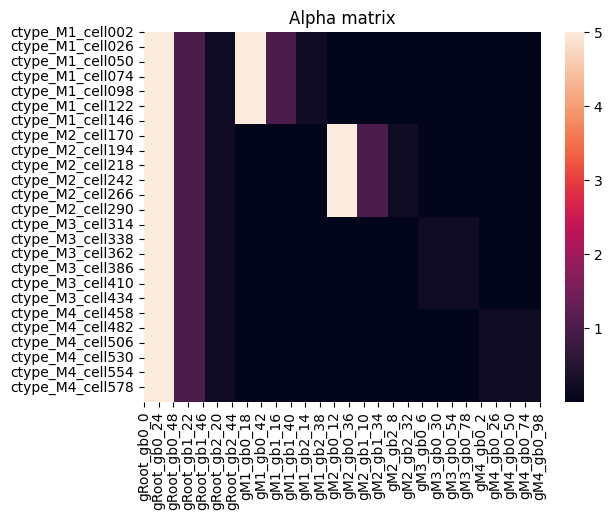

Sampling p's from Dirichlet distribution...
Sampling cell total UMIs from logNormal distribution...
M1 10 3.0
M2 10 3.0
M3 10 3.0
M4 10 3.0
Sampling cells from multinomial distribution...


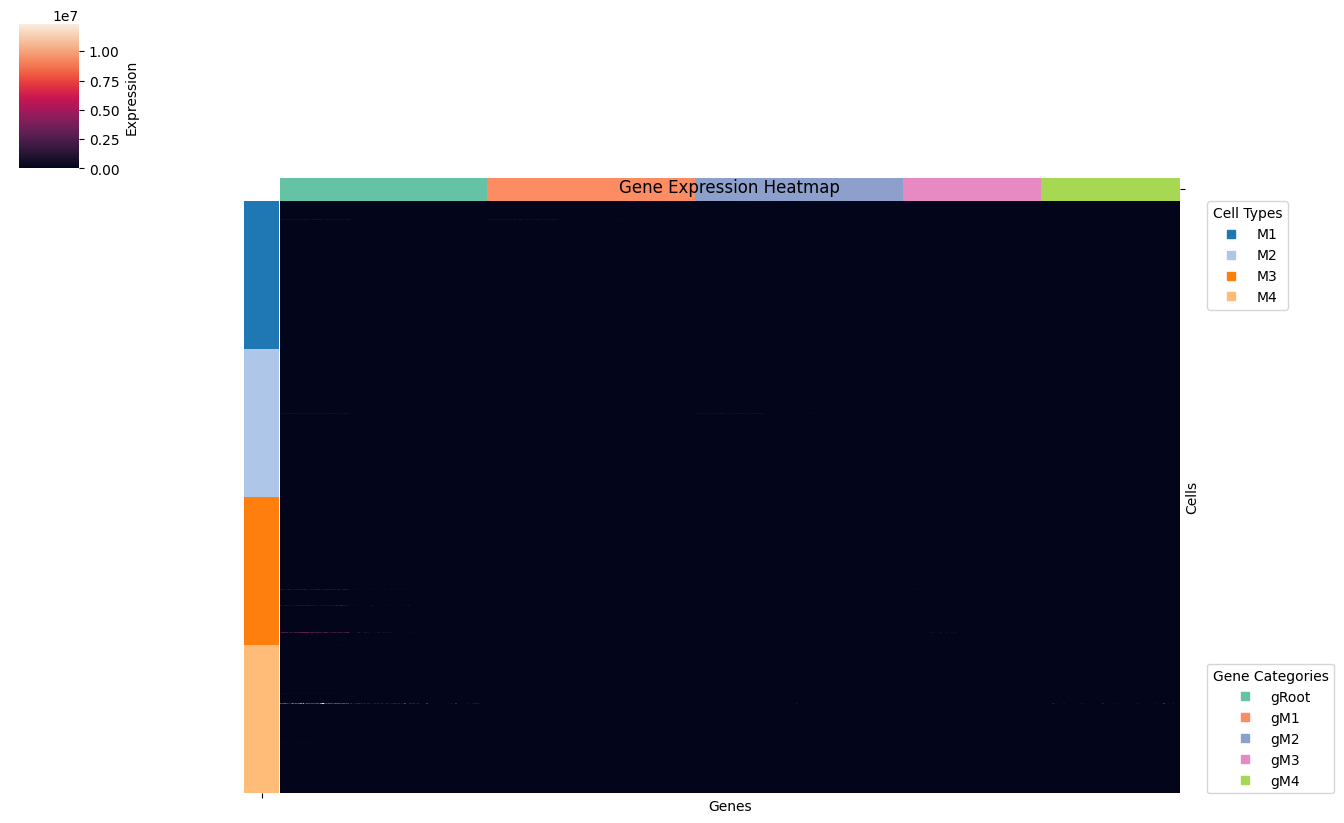

Saving anndata to: ../sim_data/adata/adata_100.h5ad


/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


In [3]:
data_df, adata = get_data_and_visualize(tree_id=100)

sc.pp.normalize_total(adata, target_sum=1e4)

#### Compute CME

In [3]:
sys.path.append('../CME')
from CME_func import CME, CME_correction

/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


<Axes: >

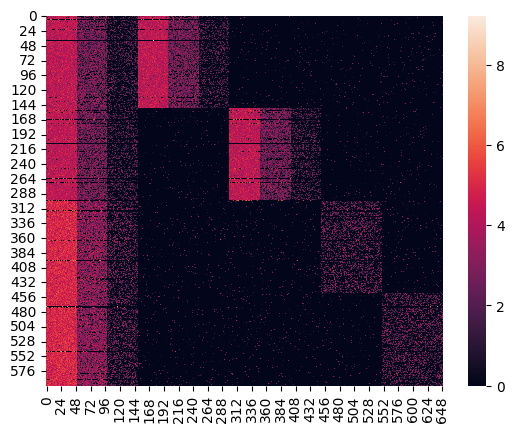

In [5]:
sns.heatmap(np.log(adata.X+1))

In [15]:
import importlib
import sys
importlib.reload(sys.modules[CME.__module__])
from CME_func import CME, CME_correction

/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


<Axes: >

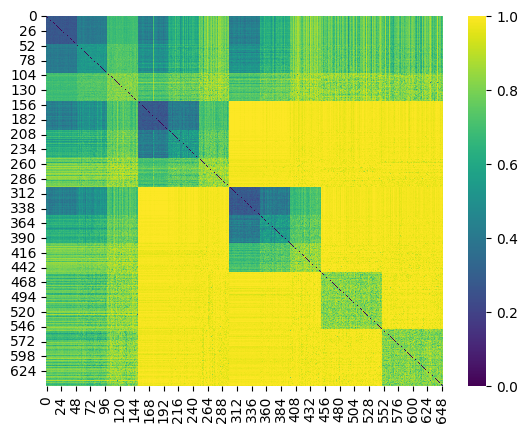

In [9]:
X = adata.X.T.astype(np.float32)

X_normed = X / X.sum(axis=1)[None,:].T * 1e4
#print(X_normed.sum(axis=1))
#print(X_normed)

cme = CME(X_normed, normalize=True, cuda=True)
sns.heatmap(cme, cmap='viridis')

##### Manual CME and Correction

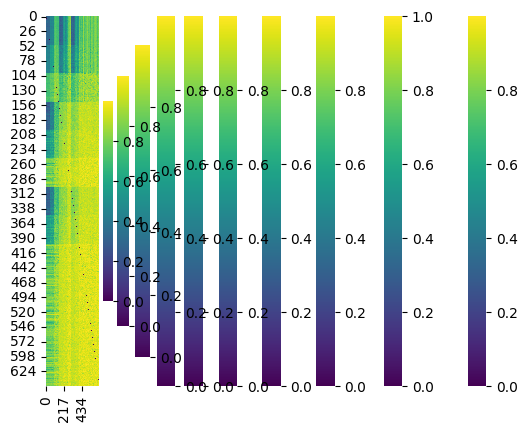

In [90]:
null_CME = []

X_shuffled = X_normed.astype(dtype=np.float32)

iteration = 10

for i in range(iteration):
    for row in X_shuffled:
        np.random.shuffle(row)

    X_shuffled = X_shuffled / X_shuffled.sum(axis=1)[None,:].T * 1e4

    cme_shuffled = CME(X_shuffled, normalize=True)
    sns.heatmap(cme_shuffled, cmap='viridis')
    null_CME.append(cme_shuffled)

null_CME_ary = np.array(null_CME)

import pickle

filename = "null_CME_"+str(iteration)+".pkl"
with open(filename, "wb") as file:
        pickle.dump(null_CME_ary, file, protocol=pickle.HIGHEST_PROTOCOL)


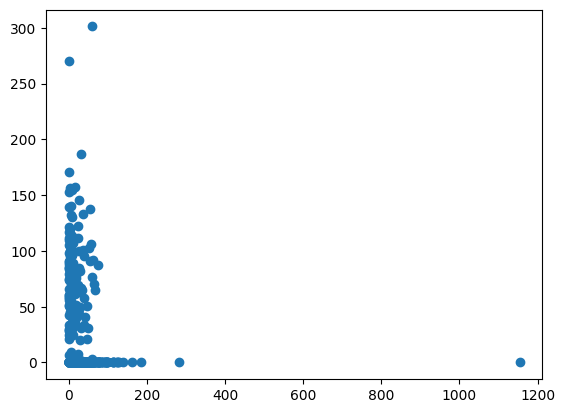

In [94]:
plt.scatter(adata.X.T[54], adata.X.T[182])

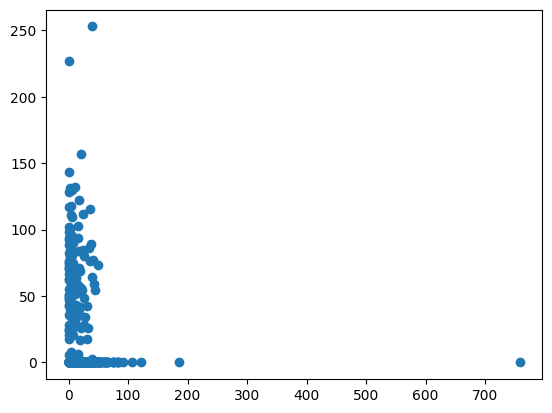

In [92]:
plt.scatter(X_normed[54], X_normed[182])

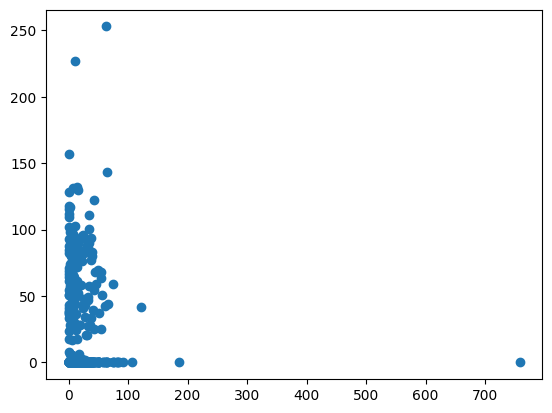

In [93]:
plt.scatter(X_shuffled[54], X_shuffled[182])

In [117]:
filename = "null_CME_10.pkl"
with open(filename, "rb") as file:
        loaded_data = pickle.load(file)

cme_rank = np.zeros(cme.shape)

for i in range(cme.shape[0]):
    for j in range(cme.shape[1]):
        cme_rank[i, j] = np.sum(loaded_data[:, i, j] > cme[i, j])

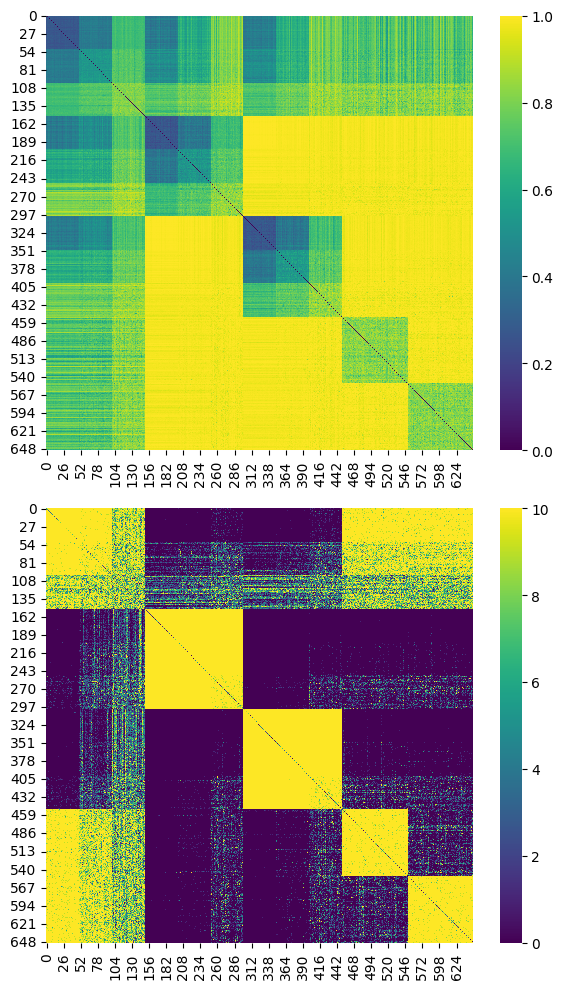

In [118]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))

sns.heatmap(cme, cmap='viridis', ax=axes[0])
sns.heatmap(cme_rank, cmap='viridis', ax=axes[1])

plt.tight_layout()
plt.show()

##### CME correction

In [16]:
cme_corrected = CME_correction(X_normed, cme, cuda=True, iterations=50)

In [ ]:
cme_corrected = cme.copy()
cme_corrected[cme_rank >= 9] = 0
cme_corrected[(cme_rank >= 2) &(cme_rank <=8)] = 0.5

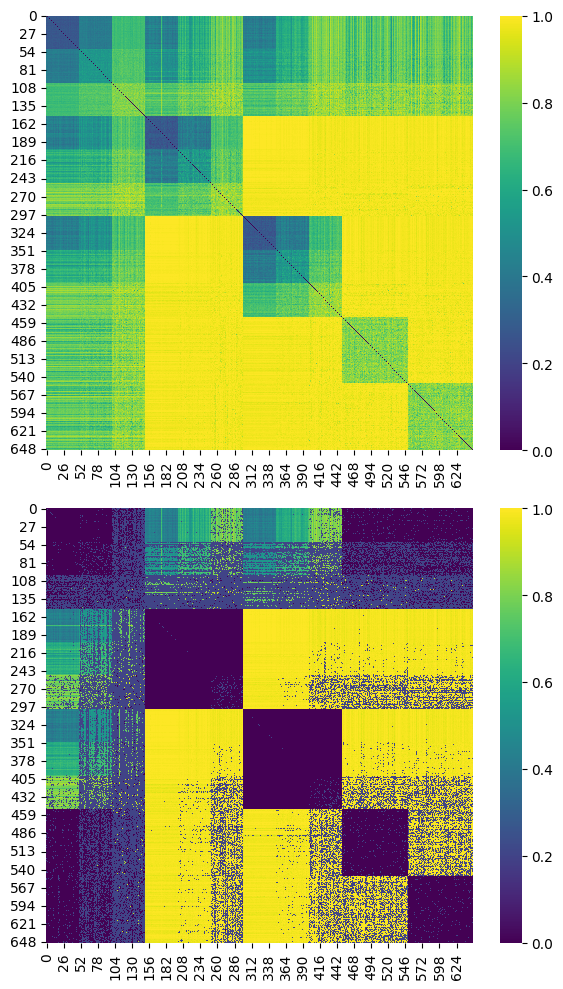

In [17]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))

#sns.heatmap(cme_rank, cmap='viridis', ax=axes[0])
sns.heatmap(cme, cmap='viridis', ax=axes[0])
sns.heatmap(cme_corrected, cmap='viridis', ax=axes[1])

plt.tight_layout()
plt.show()

##### No Normalize CME

<Axes: >

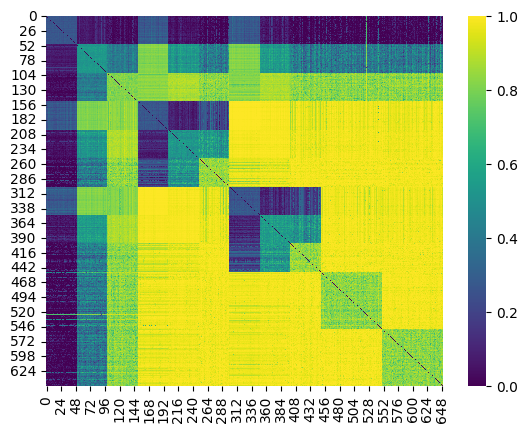

In [ ]:
cme = CME(adata.X.T, normalize=False)
sns.heatmap(cme, cmap='viridis')

#### CM data analyze

In [ ]:
import sys
sys.path.append('../CME')
from CME_func import CME, CME_correction
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import scanpy as sc, anndata as ad

import importlib
import sys
importlib.reload(sys.modules[CME.__module__])
from CME_func import CME, CME_correction

def compute_cme_and_plot(X, tp_cutoff=0.9, fp_cutoff=0.1, cuda=False):
    cme = CME(X, normalize=True, cuda=cuda)
    cme_corrected = CME_correction(X, cme, tp_cutoff=tp_cutoff, fp_cutoff=fp_cutoff, cuda=cuda)
    _, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))

    sns.heatmap(cme, cmap='viridis', ax=axes[0])
    sns.heatmap(cme_corrected, cmap='viridis', ax=axes[1])

    plt.tight_layout()
    plt.show()


def get_selected_genes(adata, gene_set, convert=False):

    if convert:
        gene_index = adata.var.index[pd.Index(adata.var["feature_name"]).get_indexer(gene_set)]
    else:
        gene_index = gene_set

    select_data = adata[:, gene_index]
    return select_data


def cme_process_data(file_path, gene_set, convert=False, tp_cutoff=0.9, fp_cutoff=0.1, cuda=False):
    adata = ad.read_h5ad(file_path)
    sc.pp.normalize_total(adata, target_sum=1e4)
    genes_to_keep = adata.X.sum(axis=0) > 100
    filtered_data = adata[:, genes_to_keep]

    select_data, _ = get_selected_genes(filtered_data, gene_set, convert)
    X = select_data.X.T.toarray()
    
    compute_cme_and_plot(X, tp_cutoff, fp_cutoff, cuda=cuda)

/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


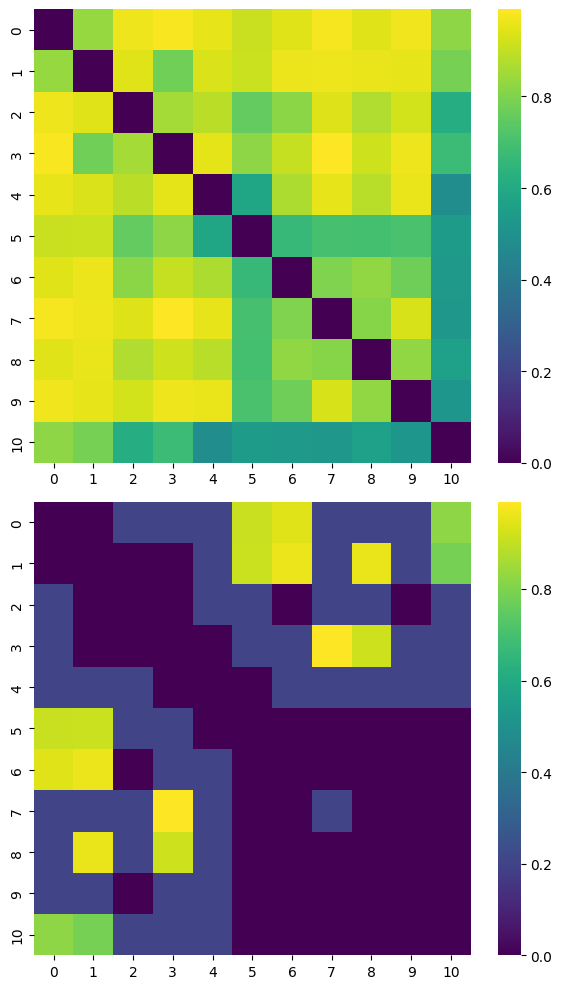

In [ ]:
gene_set = ["NPPA", "NPPB", "SPOCK1", "SLC6A6", "GLP1R", "RAPGEF4", "GUCY1A1", "CLIC6", "EDIL3", "GNAQ", "HECW2"]
file_path = '../CM_data/sedman_normal_cm_9_20.h5ad'

cme_process_data(file_path, gene_set, True, tp_cutoff=0.7, fp_cutoff=0.1, cuda=True)

/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


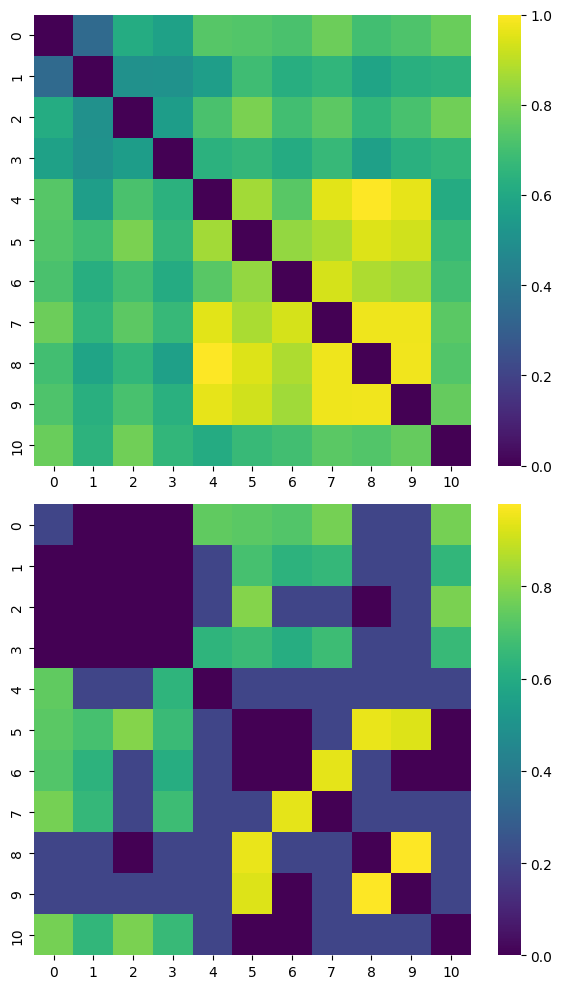

In [24]:
file_path = '../CM_data/sedman_res_one_new2.h5ad'

cme_process_data(file_path, gene_set, tp_cutoff=0.7, fp_cutoff=0.1, cuda=True)

#### Find all candidate genes who are mutually exclusive against the CM genes.

In [2]:
import importlib
import sys
sys.path.append('../CME')

#importlib.reload(sys.modules[CME.__module__])
from CME_func import CME, CME_correction
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

/home/shadeform/anaconda3/envs/FAST_CME/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [19]:
def get_selected_genes(adata, gene_set):
    gene_idx = adata.var.index.get_indexer(gene_set)
    gene_idx = gene_idx.astype(np.int32)


def compute_and_correct_cme(adata, gene_set, tp_cutoff=0.9, fp_cutoff=0.1, cuda=False):
    gene_idx = get_selected_genes(adata, gene_set)
    X = adata.X.T.toarray()
    
    cme = CME(X, normalize=True, feature_indices=gene_idx, cuda=cuda)
    print("finished CME")
    cme_corrected = CME_correction(X, cme, feature_indices=gene_idx, tp_cutoff=tp_cutoff, fp_cutoff=fp_cutoff, cuda=cuda)
    print("finished CME correction")
    return cme, cme_corrected


def plot_cme_and_correction(file_path, gene_set, tp_cutoff=0.9, fp_cutoff=0.1, cuda=False):
    adata = ad.read_h5ad(file_path)
    sc.pp.normalize_total(adata, target_sum=1e4)
    
    genes_to_keep = adata.X.sum(axis=0) > 100
    filtered_data = adata[:, genes_to_keep]

    cme, corrected_cme = compute_and_correct_cme(
        filtered_data, gene_set, tp_cutoff, fp_cutoff, cuda
    )

    _, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 10))

    sns.heatmap(cme, cmap='viridis', ax=axes[0])
    sns.heatmap(corrected_cme, cmap='viridis', ax=axes[1])

    plt.tight_layout()
    plt.show()


In [ ]:
# All the files.
file_path = '../CM_data/sedman_res_one_new2.h5ad'
file_path = '../CM_data/sedman_normal_cm_9_20.h5ad'

In [ ]:
file_path = '../CM_data/sedman_normal_cm_9_20.h5ad'

gene_set = ["NPPA", "NPPB", "SPOCK1", "SLC6A6"]

plot_cme_and_correction(file_path, gene_set, cuda=True)

finished CME


In [ ]:
# Reindex the adata
adata.var.set_index("feature_name", inplace=True)
adata.var

#### Test Normalize

In [ ]:
X=adata.X.T

In [ ]:
np.median(X[55][np.nonzero(X[55])])

16.177364

In [ ]:
median_ary = np.apply_along_axis(lambda v: np.median(v[np.nonzero(v)]), 1, X)

In [ ]:
X_normed = X / median_ary[:, None]

In [ ]:
 X.sum(axis=1)[:,None].shape

(650, 1)